<a href="https://colab.research.google.com/github/shannonmalach/Geospatial_Python_Projects/blob/main/Fairfax_City_Shortest_Walking_Path_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Shortest Walking Paths Between Fairfax City Parks

##### Shortest Path Analysis
##### Shannon Malach

In [ ]:
# installing libaries
!pip install osmnx

import osmnx as ox
import networkx as nx

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 4.5 MB/s eta 0:00:00


In [ ]:
# defining the place name to extract data from
place_name = "Fairfax, Virginia, United States"

# getting the boundary data as geodataframe
area = ox.geocode_to_gdf(place_name)
area

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-77.33505 38.85267, -77.33485 38.851...",-77.335049,38.832797,-77.268624,38.871692,348370371,relation,206874,38.846224,-77.306373,boundary,administrative,12,0.580474,city,Fairfax,"Fairfax, Virginia, 20030, United States"


<Axes: >

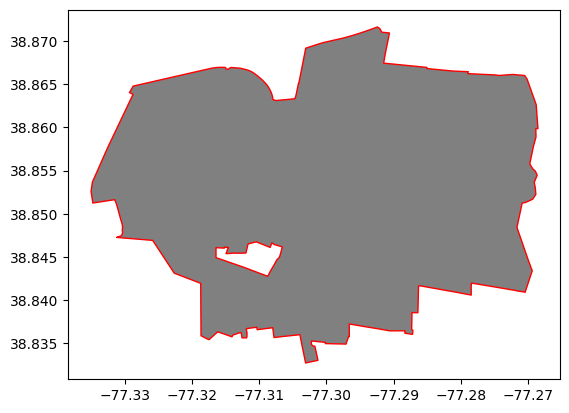

In [ ]:
# plotting the geometry
area.plot(facecolor = "grey", edgecolor = "red")

MultiDiGraph with 5519 nodes and 15486 edges


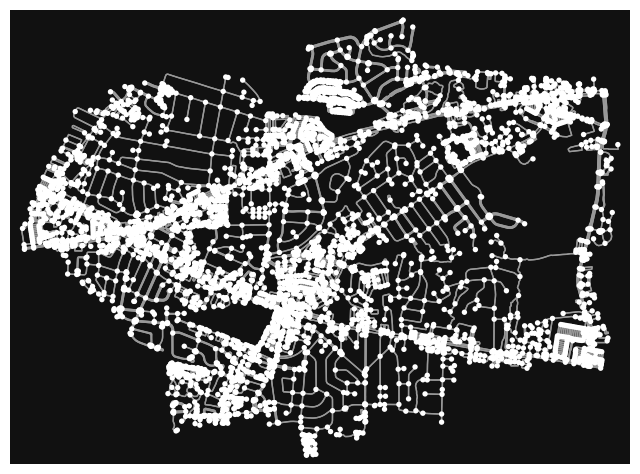

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
# retrieving the walk network type for this area
walk = ox.graph_from_place(
    place_name,
    network_type='walk'
)

# printing basic info of the network
print(walk)

# displaying a graph of the walk network
ox.plot_graph(walk)

<Axes: >

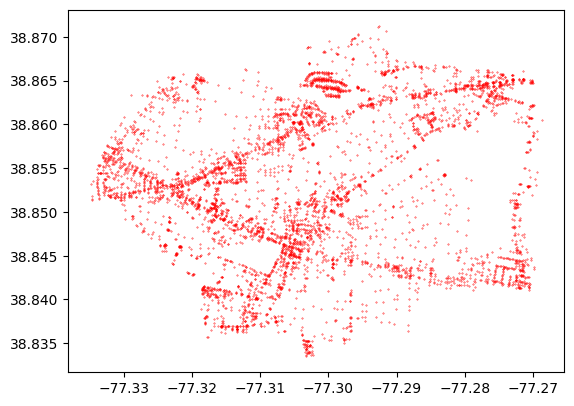

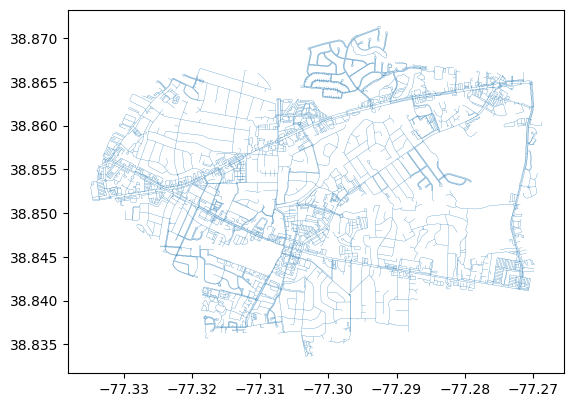

In [ ]:
# converting the MultiDiGraph to GeoPandas GeoDataFrames
gdf_nodes, gdf_edges = ox.graph_to_gdfs(walk)
gdf_nodes = gdf_nodes.reset_index()
gdf_edges = gdf_edges.reset_index()

# plotting nodes geodataframe
gdf_nodes.plot(markersize = 0.1, color = "red")
# plotting edges geodataframe
gdf_edges.plot(lw = 0.1)

In [ ]:
# reprojecting to EPSG: 3857
walk = ox.project_graph(walk, to_crs='EPSG:3857')

# getting the nodes and edges gdf to update the length column
gdf_nodes, gdf_edges = ox.graph_to_gdfs(walk)
gdf_nodes = gdf_nodes.reset_index()
gdf_edges = gdf_edges.reset_index()

# checking that the old length column is not the same geometric length with new CRS
print(gdf_edges['length'][0], gdf_edges.geometry[0].length)
print(gdf_edges['length'][8], gdf_edges.geometry[8].length)
print(gdf_edges['length'][100], gdf_edges.geometry[100].length)

75.82939513309627 97.47065531213742
57.661197844466045 74.11747520912637
164.43208109912473 211.40035081727447


In [ ]:
# updating the length column based on geometric length on the geodataframe
gdf_edges['length'] = gdf_edges.geometry.length

# converting the geodataframes back to multidigraph for further analysis
graph_attrs = {"crs": "EPSG:3857"}                   # graph CRS
gdf_nodes = gdf_nodes.set_index(['osmid'])           # node identifier
gdf_edges = gdf_edges.set_index(['u','v','key'])     # edge identifier

# converting geodataframe to multidigraph
G_new = ox.graph_from_gdfs(gdf_nodes = gdf_nodes, gdf_edges = gdf_edges, graph_attrs = graph_attrs)

In [ ]:
# creating a new graph to add travel times for edges
G_new = ox.add_edge_travel_times(ox.add_edge_speeds(G_new))

In [ ]:
# converting the graph to GeoDataFrames to contain geometry
nodes, edges = ox.graph_to_gdfs(G_new)

# printing edge lengths
print(edges[['length']].head())

                               length
u          v          key            
49594858   5518324513 0     97.470655
           5518324508 0    285.614395
           5518324516 0    296.830134
5518324513 5518324509 0     12.717370
           49594858   0     97.470655


In [ ]:
# defining walking speed as 5 km/h
walking_speed_m_per_min = 5000 / 60 # Speed in meters per minute

# calculating 'travel_time_min' and add it as an edge attribute to G_new
# iterating through each edge in the graph (u, v, key, data)
for u, v, key, data in G_new.edges(keys=True, data=True):
    # The 'length' attribute should already be available in the edge data
    # as it was added in previous steps (e.g., ox.add_edge_speeds).
    data['travel_time_min'] = data['length'] / walking_speed_m_per_min

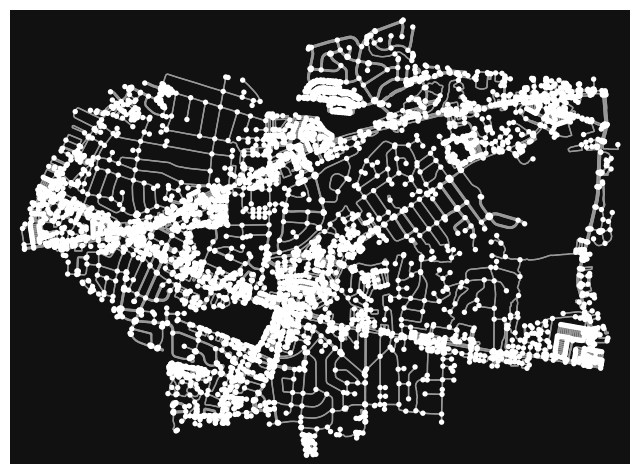

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
# displaying the updated network graph
ox.plot_graph(G_new)

In [ ]:
# geocoding the address
address = "4400 University Dr, Fairfax, VA 22030"

origin_point = ox.geocode(address)

# finding the nearest node
origin_node = ox.distance.nearest_nodes(
    G_new,
    origin_point[1],
    origin_point[0]
)

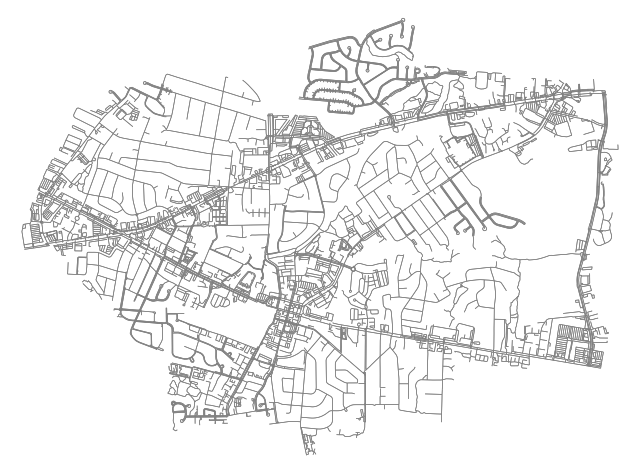

In [ ]:
# defining the time thresholds
time_thresholds = [5, 10, 15]

iso_colors = ['green', 'orange', 'red']

# creating a plot
fig, ax = ox.plot_graph(
    G_new,
    bgcolor='white',
    node_size=0,
    edge_color='gray',
    edge_linewidth=0.5,
    show=False,
    close=False
)

In [ ]:
# defining the time thresholds and colors
time_thresholds = [5, 10, 15]
iso_colors = ['green', 'orange', 'red']

# generating the isochrones
for threshold_value, color in zip(time_thresholds, iso_colors):

    # creating a subgraph to display what is reachable in the time thresholds
    subgraph = nx.ego_graph(
        G_new,
        origin_node,
        radius=threshold_value,
        distance='travel_time_min'
    )

    # converting to GeoDataFrames
    sub_nodes, sub_edges = ox.graph_to_gdfs(subgraph)

    # plotting the isochrone edges
    sub_edges.plot(
        ax=ax,
        fc=color,
        ec=color,
        lw=0.5,
        alpha=0.5,
        zorder=-1
    )

# showing the final plot
plt.show()

In [ ]:
# defining total network length
total_length_m = sub_edges.geometry.length.sum()
total_length_km = total_length_m / 1000

# displaying the total network length
print(f"\n{threshold_value}-Minute Isochrone")
print(f"Total Network Length: {total_length_km:.2f} km")


15-Minute Isochrone
Total Network Length: 47.90 km


In [ ]:
from shapely.ops import unary_union

# creating a 75-meter buffer around network
buffer_geom = sub_edges.buffer(75)

# merging buffers into one polygon
accessible_area = unary_union(buffer_geom)

# calculating the area in square meters
area_sq_m = accessible_area.area

# converting to square kilometers
area_sq_km = area_sq_m / 1_000_000

# printing the total isochrone area
print(f"Total Isochrone Area: {area_sq_km:.2f} sq km")

Total Isochrone Area: 1.21 sq km


In [ ]:
place_name = "Fairfax, Virginia, USA"

In [ ]:
# retrieving features with park tags
tags = {
    "leisure": "park"
}

parks = ox.features_from_place(
    place_name,
    tags=tags
)

In [ ]:
# keeping only polygon geometries in order to find "footprints"
parks = parks[
    parks.geometry.type.isin(
        ["Polygon", "MultiPolygon"]
    )
]

In [ ]:
# projecting to a CRS
parks_proj = parks.to_crs(
    parks.estimate_utm_crs()
)

# calculating centroids
parks_proj['centroid'] = (
    parks_proj.geometry.centroid
)

# creating a centroid GeoDataFrame
park_centroids = gpd.GeoDataFrame(
    parks_proj[['name']],
    geometry=parks_proj['centroid'],
    crs=parks_proj.crs
)

In [ ]:
# printing the results
print(parks_proj[['name', 'geometry']].head())
print(park_centroids.head())

                                   name  \
element  id                               
relation 1991149   Thaiss Memorial Park   
         6915603            Kutner Park   
         9280343    Eleven Oaks Commons   
way      49362640         Van Dyck Park   
         49705281                   NaN   

                                                            geometry  
element  id                                                           
relation 1991149   POLYGON ((303090.556 4304145.945, 303143.299 4...  
         6915603   POLYGON ((297859.78 4303504.684, 297779.897 43...  
         9280343   POLYGON ((299525.279 4301184.338, 299526.114 4...  
way      49362640  POLYGON ((300663.99 4302900.21, 300649.699 430...  
         49705281  POLYGON ((300752.674 4302742.853, 300759.722 4...  
                                   name                        geometry
element  id                                                            
relation 1991149   Thaiss Memorial Park  POINT (303090.10

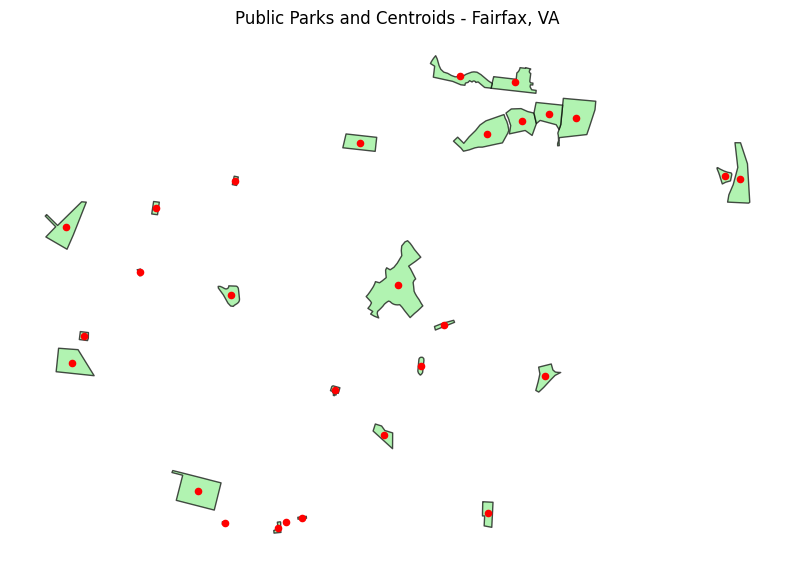

In [ ]:
# defining the figure
fig, ax = plt.subplots(figsize=(10,10))

# colorizing park polygons
parks_proj.plot(
    ax=ax,
    color='lightgreen',
    edgecolor='black',
    alpha=0.7
)

# colorizing centroids
park_centroids.plot(
    ax=ax,
    color='red',
    markersize=20
)

# defining the title
plt.title(
    "Public Parks and Centroids - Fairfax, VA"
)

plt.axis('off')

# displaying the plot
plt.show()

In [ ]:
# importing combinations library
from itertools import combinations

In [ ]:
# selecting the sample of the first four parks
parks_sample = (
    park_centroids
    .head(4)
    .reset_index(drop=True)
)

# creating unique origin-destination index pairs
comb = list(combinations([0, 1, 2, 3], 2))

print(comb)

[(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]


In [ ]:
# reprojecting parks_sample to match the CRS of G_new
parks_sample = parks_sample.to_crs(G_new.graph['crs'])

# verifyig the CRS is now consistent
print(f"CRS of G_new: {G_new.graph['crs']}")
print(f"CRS of parks_sample: {parks_sample.crs}")

CRS of G_new: EPSG:3857
CRS of parks_sample: EPSG:3857


In [ ]:
# creating a list called shortest_path
shortest_path = []

In [ ]:
# looping through each origin-destination pair
for origin_idx, dest_idx in comb:

    # retrieving centroid geometry
    origin_geom = parks_sample.loc[
            origin_idx,
            'geometry'
        ]
    dest_geom = parks_sample.loc[
            dest_idx,
            'geometry'
        ]

    # finding the nearest network node to the origin
    origin_node = ox.distance.nearest_nodes(
            G_new, # Changed from G to G_new
            X=origin_geom.x,
            Y=origin_geom.y
        )

    # finding the nearest network node to the destination
    destination_node = ox.distance.nearest_nodes(
            G_new, # Changed from G to G_new
            X=dest_geom.x,
            Y=dest_geom.y
        )

    # calculating the shortest route
    if origin_node == destination_node:
        total_travel_time = 0
        route = [origin_node] # Still store a route, but with 0 time
    else:
        route = nx.shortest_path(
                G_new, # Changed from G to G_new
                origin_node,
                destination_node,
                weight='travel_time_min'
            )

        # calculating total travel time
        total_travel_time = int(
                sum(
                    ox.routing.route_to_gdf(
                        G_new, # Changed from G to G_new
                        route,
                        weight="travel_time_min"
                    )["travel_time_min"]
                )
            )

    shortest_path.append(route)

    # printing the travel times between origins and destinations
    print(
            f"The travel time between origin "
            f"public park {origin_idx} and "
            f"destination public park {dest_idx} "
            f"is {total_travel_time} minutes."
        )

The travel time between origin public park 0 and destination public park 1 is 88 minutes.
The travel time between origin public park 0 and destination public park 2 is 78 minutes.
The travel time between origin public park 0 and destination public park 3 is 47 minutes.
The travel time between origin public park 1 and destination public park 2 is 57 minutes.
The travel time between origin public park 1 and destination public park 3 is 51 minutes.
The travel time between origin public park 2 and destination public park 3 is 37 minutes.


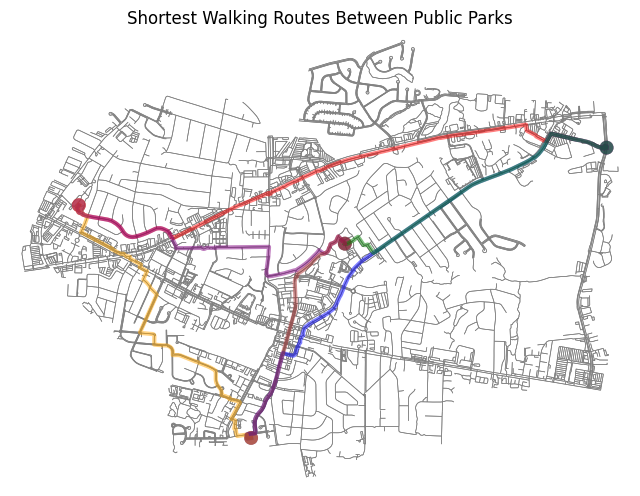

In [ ]:
# defining colors for specific routes
route_colors = [
    'red',
    'blue',
    'green',
    'orange',
    'purple',
    'brown'
]

# defining the figure
fig, ax = ox.plot_graph(
    G_new,
    bgcolor='white',
    node_size=0,
    edge_color='gray',
    edge_linewidth=0.5,
    show=False,
    close=False
)

# using a loop to plot each route
for route, color in zip(shortest_path, route_colors):

    ox.plot_graph_route(
        G_new,
        route,
        route_color=color,
        route_linewidth=3,
        node_size=0,
        ax=ax,
        show=False,
        close=False
    )

# defining the title
plt.title(
    "Shortest Walking Routes Between Public Parks"
)

# displaying the plot
plt.show()